In [1]:
import numpy as np

# Duomenų generavimas

In [3]:
N = 1000
ground_truth = np.random.choice([0, 1], size = N).astype(np.float32)
print(ground_truth[:10])
predictions = ground_truth * 0.3 + 0.4 + np.random.randn(N) * 0.2
print(predictions[:10])

[1. 0. 0. 1. 1. 1. 1. 1. 0. 0.]
[0.90788773 0.06034537 0.71551868 0.55489451 0.65753963 0.6190435
 0.61540232 1.21301934 0.34036481 0.66627062]


# Modelio vertinimo metrikos

Iš pradžių reikia paskaičiuoti TP, TN, FP, FN. Tada galima skaičiuoti tikslumą (_accuracy_), atkūrimą (_recall_), preciziškumą (_precision_), F1.

$Accuracy = \frac{TP + TN}{TP + FP + TN + FN}$

$Recall = \frac{TP}{TP + FN}$

$Precision = \frac{TP}{TP + FP}$

$F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$

In [16]:
def calculate_confusion_matrix(ground_truth, predictions, threshold = 0.5):
  predictions_thr = (predictions > threshold).astype(np.float32)

  tp = np.sum(np.bitwise_and(ground_truth == 1, predictions_thr == 1))
  tn = np.sum(np.bitwise_and(ground_truth == 0, predictions_thr == 0))
  fp = np.sum(np.bitwise_and(ground_truth == 0, predictions_thr == 1))
  fn = np.sum(np.bitwise_and(ground_truth == 1, predictions_thr == 0))

  return {
      'TP': tp,
      'TN': tn,
      'FP': fp,
      'FN': fn,
  }


In [6]:
print(calculate_confusion_matrix(ground_truth, predictions))

{'TP': np.int64(411), 'TN': np.int64(337), 'FP': np.int64(171), 'FN': np.int64(81)}


In [7]:
def calculate_metrics(confusion_matrix):
  tp = confusion_matrix['TP']
  fp = confusion_matrix['FP']
  tn = confusion_matrix['TN']
  fn = confusion_matrix['FN']

  accuracy = (tp + tn) / (tp + tn + fp + fn)
  recall = tp / (tp + fn)
  precision = tp / (tp + fp)
  f1 = 2 * (recall * precision) / (recall + precision)

  return {
      'Accuracy': float(accuracy),
      'Recall': float(recall),
      'Precision': float(precision),
      'F1': float(f1),
  }

In [19]:
from pprint import pprint
metrics = calculate_metrics(calculate_confusion_matrix(ground_truth, predictions))
pprint(metrics)

{'Accuracy': 0.748,
 'F1': 0.7653631284916201,
 'Precision': 0.7061855670103093,
 'Recall': 0.8353658536585366}


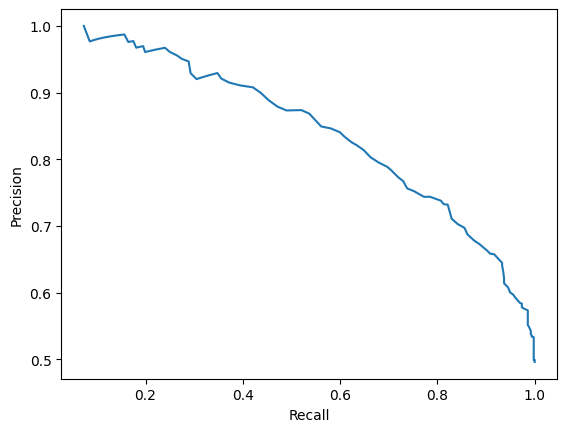

In [20]:
# precision-recall curve
thresholds = np.linspace(0, 1, 120)
precisions = np.zeros_like(thresholds)
recalls = np.zeros_like(thresholds)

for i, thr in enumerate(thresholds):
  metrics = calculate_metrics(calculate_confusion_matrix(ground_truth, predictions, threshold = thr))
  precisions[i] = metrics['Precision']
  recalls[i] = metrics['Recall']

import matplotlib.pyplot as plt

plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()